In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as sm
from pandas.tseries.offsets import *

In [11]:
pred_path = "final_results.csv"
pred = pd.read_csv(pred_path, parse_dates=["date"])
pred

,Unnamed: 0,date,returns
0,0,2015-01-01,0.028056
1,1,2015-02-01,0.069680
2,2,2015-03-01,-0.008274
3,3,2015-04-01,-0.025945
4,4,2015-05-01,0.026957
...,...,...,...
127,127,2025-08-01,0.000000
128,128,2025-09-01,0.000000
129,129,2025-10-01,0.000000
130,130,2025-11-01,0.000000


In [12]:
pred = pred[pred['returns'] != 0]
pred

,Unnamed: 0,date,returns
0,0,2015-01-01,0.028056
1,1,2015-02-01,0.069680
2,2,2015-03-01,-0.008274
3,3,2015-04-01,-0.025945
4,4,2015-05-01,0.026957
...,...,...,...
121,121,2025-02-01,0.034675
122,122,2025-03-01,0.018731
123,123,2025-04-01,0.001206
124,124,2025-05-01,-0.012591


In [35]:
snp_returns_path = "mkt_ind.csv"
snp_returns = pd.read_csv(snp_returns_path)
snp_returns = snp_returns[snp_returns["year"] >= 2015]
snp_returns

,rf,year,month,ret
120,0.0000,2015,1,-0.031041
121,0.0000,2015,2,0.054893
122,0.0000,2015,3,-0.017396
123,0.0000,2015,4,0.008521
124,0.0000,2015,5,0.010491
...,...,...,...,...
241,0.0033,2025,2,-0.014242
242,0.0034,2025,3,-0.057545
243,0.0035,2025,4,-0.007625
244,0.0038,2025,5,0.061524


In [31]:
monthly_portfolio = pred.copy()
monthly_portfolio['date'] = pd.to_datetime(pred['date'])

# Extract year and month
monthly_portfolio['year'] = monthly_portfolio['date'].dt.year.copy()
monthly_portfolio['month'] = monthly_portfolio['date'].dt.month.copy()
monthly_portfolio.drop

monthly_portfolio.drop('Unnamed: 0', axis=1, inplace=True)
monthly_portfolio

,date,returns,year,month
0,2015-01-01,0.028056,2015,1
1,2015-02-01,0.069680,2015,2
2,2015-03-01,-0.008274,2015,3
3,2015-04-01,-0.025945,2015,4
4,2015-05-01,0.026957,2015,5
...,...,...,...,...
121,2025-02-01,0.034675,2025,2
122,2025-03-01,0.018731,2025,3
123,2025-04-01,0.001206,2025,4
124,2025-05-01,-0.012591,2025,5


### Sharpe Ratio

In [13]:
sharpe = (
    monthly_portfolio["returns"].mean() / monthly_portfolio["returns"].std() * np.sqrt(12)
)  # Sharpe ratio is annualized
print("Sharpe Ratio:", sharpe)
ann_std = monthly_portfolio["returns"].std() * np.sqrt(12)
print("Annualized Standard Deviation:", ann_std)

Sharpe Ratio: 0.9089533000527759
Annualized Standard Deviation: 0.20941886410225385


In [33]:
monthly_portfolio_merged = monthly_portfolio.merge(snp_returns, how="inner", on=["year", "month"])
monthly_portfolio_merged

,date,returns,year,month,rf,ret
0,2015-01-01,0.028056,2015,1,0.0000,-0.031041
1,2015-02-01,0.069680,2015,2,0.0000,0.054893
2,2015-03-01,-0.008274,2015,3,0.0000,-0.017396
3,2015-04-01,-0.025945,2015,4,0.0000,0.008521
4,2015-05-01,0.026957,2015,5,0.0000,0.010491
...,...,...,...,...,...,...
121,2025-02-01,0.034675,2025,2,0.0033,-0.014242
122,2025-03-01,0.018731,2025,3,0.0034,-0.057545
123,2025-04-01,0.001206,2025,4,0.0035,-0.007625
124,2025-05-01,-0.012591,2025,5,0.0038,0.061524


### Annualized Alpha

In [44]:
monthly_portfolio_merged = monthly_portfolio.merge(snp_returns, how="inner", on=["year", "month"])
# Newy-West regression for heteroskedasticity and autocorrelation robust standard errors
nw_ols = sm.ols(formula="returns ~ rf", data=monthly_portfolio_merged).fit(
    cov_type="HAC", cov_kwds={"maxlags": 3}, use_t=True
)
print(nw_ols.summary())

# Specifically, the alpha, t-statistic, and Information ratio are:
print("CAPM Alpha:", nw_ols.params["Intercept"]*12)
print("t-statistic:", nw_ols.tvalues["Intercept"])

                            OLS Regression Results                            
Dep. Variable:                returns   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     4.022
Date:                Sat, 04 Oct 2025   Prob (F-statistic):             0.0471
Time:                        21:56:16   Log-Likelihood:                 178.35
No. Observations:                 126   AIC:                            -352.7
Df Residuals:                     124   BIC:                            -347.0
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0035      0.006      0.582      0.5

### Information Ratio

In [45]:
print(
    "Information Ratio:",
    nw_ols.params["Intercept"] / np.sqrt(nw_ols.mse_resid) * np.sqrt(12),
)  # Information ratio is annualized

Information Ratio: 0.20325563903637847


### Max One-Month Loss

In [46]:
max_1m_loss = monthly_portfolio["returns"].min()
print("Max 1-Month Loss:", max_1m_loss)

Max 1-Month Loss: -0.16717109


### Max Drawdown

In [ ]:
monthly

In [48]:
# Calculate Drawdown of the long-short Portfolio
# you can use the same formula to calculate the Sharpe ratio for the long and short portfolios separately
monthly_portfolio["log_returns"] = np.log(
    monthly_portfolio["returns"] + 1
)  # calculate log returns
monthly_portfolio["cumsum_log_returns"] = monthly_portfolio["log_returns"].cumsum(
    axis=0
)  # calculate cumulative log returns
rolling_peak = monthly_portfolio["cumsum_log_returns"].cummax()
drawdowns = rolling_peak - monthly_portfolio["cumsum_log_returns"]
max_drawdown = drawdowns.max()
print("Maximum Drawdown:", max_drawdown)

Maximum Drawdown: 0.5076349172323715


### Turnover

In [49]:
# Calculate Turnover of the long portfolio and short portfolio
def turnover_count(df):
    # count the number of stocks at the begnning of each month
    start_stocks = df[["id", "date"]].copy()
    start_stocks = start_stocks.sort_values(by=["date", "id"])
    start_count = start_stocks.groupby(["date"])["id"].count().reset_index()

    end_stocks = df[["id", "date"]].copy()
    end_stocks["date"] = end_stocks["date"] - MonthBegin(
        1
    )  # shift the date to the beginning of the next month
    end_stocks = end_stocks.sort_values(by=["date", "id"])

    remain_stocks = start_stocks.merge(end_stocks, on=["date", "id"], how="inner")
    remain_count = (
        remain_stocks.groupby(["date"])["id"].count().reset_index()
    )  # count the number of stocks that remain in the next month
    remain_count = remain_count.rename(columns={"id": "remain_count"})

    port_count = start_count.merge(remain_count, on=["date"], how="inner")
    port_count["turnover"] = (
        port_count["id"] - port_count["remain_count"]
    ) / port_count[
        "id"
    ]  # calculate the turnover as the average of the percentage of stocks that are replaced each month
    return port_count["turnover"].mean()

long_positions = pred[pred["rank"] == 9]
short_positions = pred[pred["rank"] == 0]
print("Long Portfolio Turnover:", turnover_count(long_positions))
print("Short Portfolio Turnover:", turnover_count(short_positions))

In [50]:
monthly_portfolio

,date,returns,year,month,log_returns,cumsum_log_returns
0,2015-01-01,0.028056,2015,1,0.027670,0.027670
1,2015-02-01,0.069680,2015,2,0.067359,0.095029
2,2015-03-01,-0.008274,2015,3,-0.008308,0.086721
3,2015-04-01,-0.025945,2015,4,-0.026288,0.060433
4,2015-05-01,0.026957,2015,5,0.026600,0.087033
...,...,...,...,...,...,...
121,2025-02-01,0.034675,2025,2,0.034087,1.692615
122,2025-03-01,0.018731,2025,3,0.018558,1.711172
123,2025-04-01,0.001206,2025,4,0.001205,1.712378
124,2025-05-01,-0.012591,2025,5,-0.012671,1.699707


In [57]:
monthly_portfolio["cumulative returns"] = np.exp(monthly_portfolio["cumsum_log_returns"]) - 1
monthly_portfolio.tail()

,date,returns,year,month,log_returns,cumsum_log_returns,exp,cumulative returns
121,2025-02-01,0.034675,2025,2,0.034087,1.692615,4.433670,4.433670
122,2025-03-01,0.018731,2025,3,0.018558,1.711172,4.535448,4.535448
123,2025-04-01,0.001206,2025,4,0.001205,1.712378,4.542124,4.542124
124,2025-05-01,-0.012591,2025,5,-0.012671,1.699707,4.472345,4.472345
125,2025-06-01,0.064571,2025,6,0.062572,1.762279,4.825699,4.825699


In [56]:
snp_returns["log_returns"] = np.log(
    snp_returns["ret"] + 1
)  # calculate log returns
snp_returns["cumsum_log_returns"] = snp_returns["log_returns"].cumsum(
    axis=0
)
snp_returns["exp"] = np.exp(snp_returns["cumsum_log_returns"]) - 1
snp_returns

,rf,year,month,ret,log_returns,cumsum_log_returns,exp
120,0.0000,2015,1,-0.031041,-0.031533,-0.031533,-0.031041
121,0.0000,2015,2,0.054893,0.053439,0.021906,0.022148
122,0.0000,2015,3,-0.017396,-0.017549,0.004357,0.004366
123,0.0000,2015,4,0.008521,0.008485,0.012842,0.012924
124,0.0000,2015,5,0.010491,0.010437,0.023278,0.023551
...,...,...,...,...,...,...,...
241,0.0033,2025,2,-0.014242,-0.014345,1.061975,1.892078
242,0.0034,2025,3,-0.057545,-0.059267,1.002709,1.725654
243,0.0035,2025,4,-0.007625,-0.007654,0.995054,1.704872
244,0.0038,2025,5,0.061524,0.059705,1.054760,1.871286


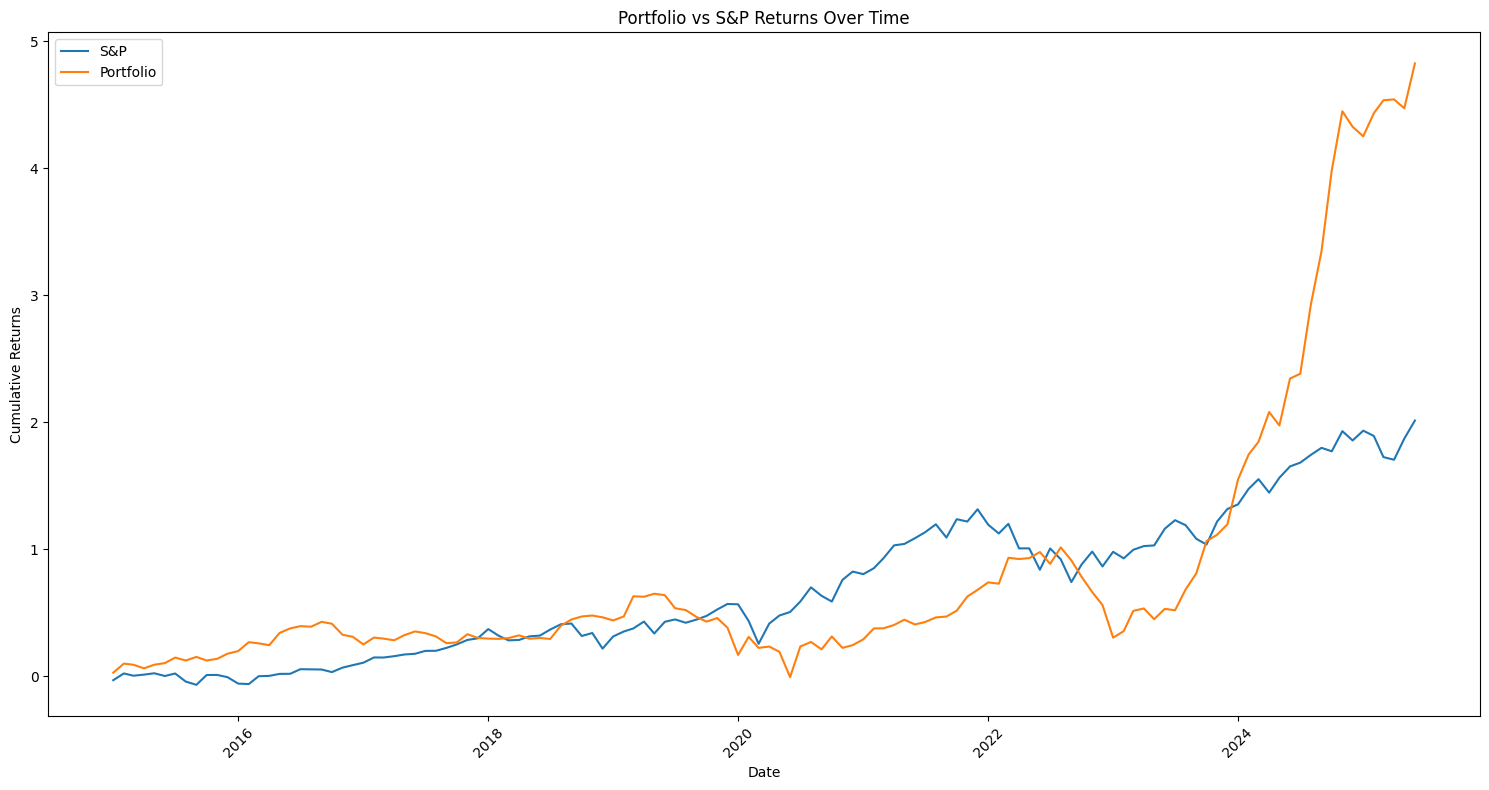

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert year and month into a datetime column
monthly_portfolio['date'] = pd.to_datetime(monthly_portfolio[['year', 'month']].assign(day=1))
snp_returns['date'] = pd.to_datetime(snp_returns[['year', 'month']].assign(day=1))  # if S&P has year/month too

# Plot
fig = plt.figure(figsize=(15, 8))
plt.plot(snp_returns["date"], snp_returns["exp"], label="S&P")
plt.plot(monthly_portfolio["date"], monthly_portfolio["cumulative returns"], label="Portfolio")

plt.xlabel("Date")
plt.ylabel("Cumulative Returns")
plt.title("Portfolio vs S&P Returns Over Time")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [63]:
monthly_portfolio

,date,returns,year,month,log_returns,cumsum_log_returns,exp,cumulative returns
0,2015-01-01,0.028056,2015,1,0.027670,0.027670,0.028056,0.028056
1,2015-02-01,0.069680,2015,2,0.067359,0.095029,0.099691,0.099691
2,2015-03-01,-0.008274,2015,3,-0.008308,0.086721,0.090592,0.090592
3,2015-04-01,-0.025945,2015,4,-0.026288,0.060433,0.062296,0.062296
4,2015-05-01,0.026957,2015,5,0.026600,0.087033,0.090932,0.090932
...,...,...,...,...,...,...,...,...
121,2025-02-01,0.034675,2025,2,0.034087,1.692615,4.433670,4.433670
122,2025-03-01,0.018731,2025,3,0.018558,1.711172,4.535448,4.535448
123,2025-04-01,0.001206,2025,4,0.001205,1.712378,4.542124,4.542124
124,2025-05-01,-0.012591,2025,5,-0.012671,1.699707,4.472345,4.472345


In [65]:
monthly_portfolio['date'] = pd.to_datetime(monthly_portfolio[['year', 'month']].assign(day=1))
monthly_portfolio

,date,returns,year,month,log_returns,cumsum_log_returns,exp,cumulative returns
0,2015-01-01,0.028056,2015,1,0.027670,0.027670,0.028056,0.028056
1,2015-02-01,0.069680,2015,2,0.067359,0.095029,0.099691,0.099691
2,2015-03-01,-0.008274,2015,3,-0.008308,0.086721,0.090592,0.090592
3,2015-04-01,-0.025945,2015,4,-0.026288,0.060433,0.062296,0.062296
4,2015-05-01,0.026957,2015,5,0.026600,0.087033,0.090932,0.090932
...,...,...,...,...,...,...,...,...
121,2025-02-01,0.034675,2025,2,0.034087,1.692615,4.433670,4.433670
122,2025-03-01,0.018731,2025,3,0.018558,1.711172,4.535448,4.535448
123,2025-04-01,0.001206,2025,4,0.001205,1.712378,4.542124,4.542124
124,2025-05-01,-0.012591,2025,5,-0.012671,1.699707,4.472345,4.472345
